In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.getcwd()

'c:\\Users\\Ducks\\Downloads\\ducks python\\fraud-detection-system\\notebooks'

In [3]:
df_og=pd.read_csv('c:\\Users\\Ducks\\Downloads\\ducks python\\fraud-detection-system\\data\\creditcard.csv')

In [4]:
df_og.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df=df_og.copy()
df.shape

(284807, 31)

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [8]:
class_0=df['Class'].value_counts()[0]
df_len=len(df)
class_1=df['Class'].value_counts()[1]
print((class_0*100)/df_len)
print((class_1*100)/df_len)

99.827251436938
0.1727485630620034


Text(0.5, 1.0, 'fraud vs legitimate transaction')

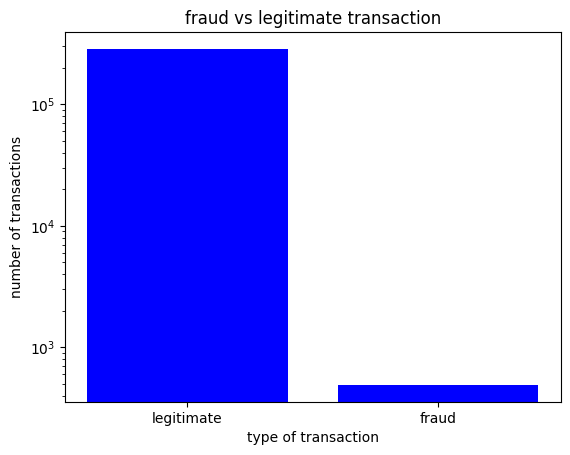

In [9]:
plt.bar(['legitimate','fraud'],[class_0,class_1],color='blue')
plt.xlabel('type of transaction')
plt.ylabel('number of transactions')
plt.yscale('log')
plt.title('fraud vs legitimate transaction')

In [10]:
lst0=[]
lst1=[]
for i in range(len(df)):
    if df['Class'][i]==0:
        lst0.append(df['Amount'][i])
    else:
        lst1.append(df['Amount'][i])

In [11]:
print(np.mean(lst0))
print(np.median(lst0))
print(np.min(lst0))
print(np.max(lst0))

88.29102242231328
22.0
0.0
25691.16


In [12]:
print(np.mean(lst1))
print(np.median(lst1))
print(np.min(lst1))
print(np.max(lst1))

122.21132113821139
9.25
0.0
2125.87


In [13]:
legitimate_amnt=df[df['Class']==0]['Amount']
fraud_amnt=df[df['Class']==1]['Amount']

(array([2.75533e+05, 5.98600e+03, 1.53200e+03, 6.26000e+02, 2.26000e+02,
        1.44000e+02, 9.20000e+01, 6.90000e+01, 3.30000e+01, 2.20000e+01,
        1.00000e+01, 1.10000e+01, 5.00000e+00, 5.00000e+00, 5.00000e+00,
        5.00000e+00, 1.00000e+00, 2.00000e+00, 0.00000e+00, 2.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([    0.    ,   513.8232,  1027.6464,  1541.4696,  2055.2928,
         2569.116 ,  3082.9392,  3596.7624,  4110.5856,  4624.4088,
         5138.232 ,  5652.0552,  6165.8784,  6679.7016,  7193.5248,
         7707.348 ,  8221.1712,  8734.9944,  9248.8176,  9762.64

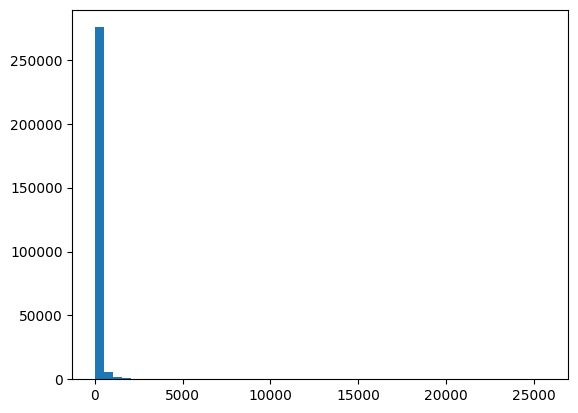

In [14]:
plt.hist(legitimate_amnt,bins=50)

(array([296.,  29.,  61.,   9.,  15.,  11.,   8.,  12.,   8.,   1.,   5.,
          2.,   5.,   2.,   3.,   2.,   3.,   4.,   3.,   2.,   0.,   1.,
          0.,   1.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   2.,   2.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([   0.    ,   42.5174,   85.0348,  127.5522,  170.0696,  212.587 ,
         255.1044,  297.6218,  340.1392,  382.6566,  425.174 ,  467.6914,
         510.2088,  552.7262,  595.2436,  637.761 ,  680.2784,  722.7958,
         765.3132,  807.8306,  850.348 ,  892.8654,  935.3828,  977.9002,
        1020.4176, 1062.935 , 1105.4524, 1147.9698, 1190.4872, 1233.0046,
        1275.522 , 1318.0394, 1360.5568, 1403.0742, 1445.5916, 1488.109 ,
        1530.6264, 1573.1438, 1615.6612, 1658.1786, 1700.696 , 1743.2134,
        1785.7308, 1828.2482, 1870.7656, 1913.283 , 1955.8004, 1998.3178,
        2040.8352, 2083.3526, 2125.87  ]),
 <BarContainer object o

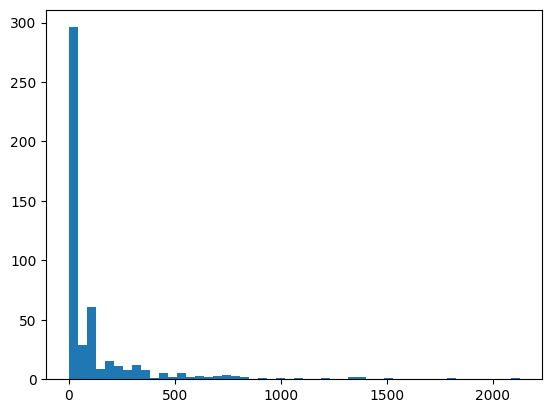

In [15]:
plt.hist(fraud_amnt,bins=50)


In [16]:
legit_time = df[df['Class'] == 0]['Time']
fraud_time = df[df['Class'] == 1]['Time']

(array([3331., 2261., 1218., 1717., 1012.,  929., 1257., 1343., 1566.,
        2822., 3916., 6003., 6443., 6694., 6739., 6224., 6047., 6300.,
        6465., 6100., 6233., 6377., 6259., 7053., 6294., 7084., 7734.,
        8392., 5987., 4703., 3235., 1867., 1299., 1878.,  828.,  970.,
         913., 1212., 2126., 3335., 3902., 5662., 6807., 6640., 6662.,
        6176., 6194., 6438., 6917., 6872., 6820., 6951., 6514., 6639.,
        6059., 6216., 6472., 5756., 4710., 3742.]),
 array([     0.        ,   2879.86666667,   5759.73333333,   8639.6       ,
         11519.46666667,  14399.33333333,  17279.2       ,  20159.06666667,
         23038.93333333,  25918.8       ,  28798.66666667,  31678.53333333,
         34558.4       ,  37438.26666667,  40318.13333333,  43198.        ,
         46077.86666667,  48957.73333333,  51837.6       ,  54717.46666667,
         57597.33333333,  60477.2       ,  63357.06666667,  66236.93333333,
         69116.8       ,  71996.66666667,  74876.53333333,  77756.

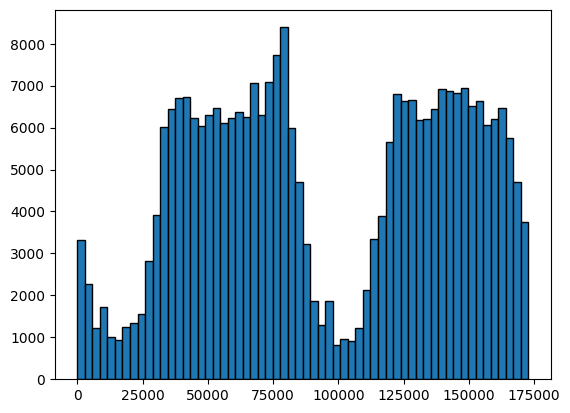

In [17]:
plt.hist(legit_time,bins=60,edgecolor='black')

(array([ 2.,  1., 21.,  6.,  8.,  4.,  8.,  6.,  5., 19.,  6.,  3., 14.,
         1., 39., 10.,  9.,  7.,  8., 13., 13.,  8.,  8., 13.,  7.,  3.,
        13.,  7.,  2., 12.,  7.,  3., 20., 21.,  3.,  9., 11.,  0.,  6.,
         0.,  2.,  2.,  1.,  3.,  4., 13.,  4.,  8.,  5.,  8., 11.,  6.,
        15., 11., 17.,  5.,  9.,  1.,  6.,  5.]),
 array([   406.        ,   3238.36666667,   6070.73333333,   8903.1       ,
         11735.46666667,  14567.83333333,  17400.2       ,  20232.56666667,
         23064.93333333,  25897.3       ,  28729.66666667,  31562.03333333,
         34394.4       ,  37226.76666667,  40059.13333333,  42891.5       ,
         45723.86666667,  48556.23333333,  51388.6       ,  54220.96666667,
         57053.33333333,  59885.7       ,  62718.06666667,  65550.43333333,
         68382.8       ,  71215.16666667,  74047.53333333,  76879.9       ,
         79712.26666667,  82544.63333333,  85377.        ,  88209.36666667,
         91041.73333333,  93874.1       ,  96706.4

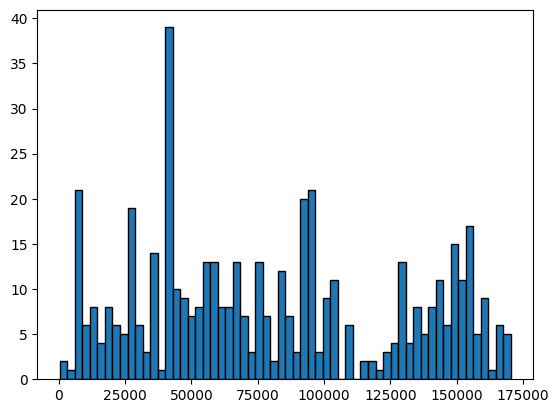

In [18]:
plt.hist(fraud_time,bins=60,edgecolor='black')

In [19]:
#find highly correlated features wtr class
corr=df.corr()
corr['Class'].sort_values()

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

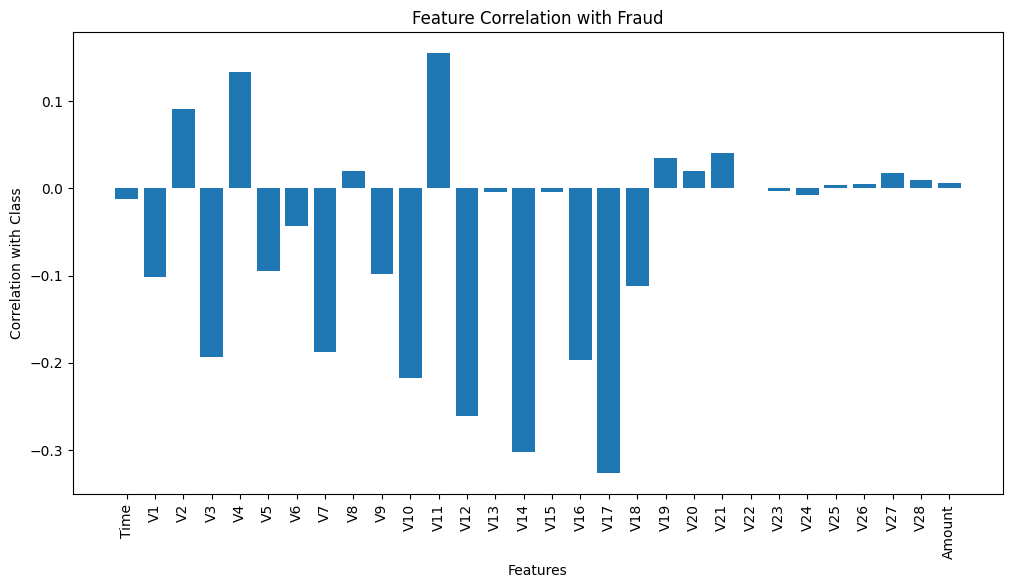

In [20]:
class_corr = corr['Class'].drop('Class')
plt.figure(figsize=(12,6))

plt.bar(class_corr.index, class_corr.values)

plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Correlation with Class')
plt.title('Feature Correlation with Fraud')

plt.show()

In [21]:
y=df['Class']
X=df.drop('Class',axis=1)

In [22]:
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(227845, 30)
(56962, 30)
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
model_lr=LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled,y_train)
y_pred_lr=model_lr.predict(X_test)

c:\Users\Ducks\Downloads\ducks python\venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[56845    19]
 [   97     1]]


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.05      0.01      0.02        98

    accuracy                           1.00     56962
   macro avg       0.52      0.50      0.51     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
model_lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr_balanced = model_lr_balanced.predict(X_test_scaled)

In [35]:
print(confusion_matrix(y_test, y_pred_lr_balanced))

print(classification_report(y_test, y_pred_lr_balanced))

[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

